# Cats vs Dogs Image Classification using SVM

## SkillCraft Technology - Machine Learning Internship

### Task 03


In [48]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [49]:
categories = ['cats', 'dogs']

data = []
labels = []

for category in categories:
    
    folder_path = os.path.join('data/train', category)
    label = categories.index(category)

    for img_name in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img_name)

        try:
            img = cv2.imread(img_path)
            img = cv2.resize(img, (64, 64))

            data.append(img)
            labels.append(label)

        except Exception as e:
            pass

In [50]:
print("Total Images Loaded:", len(data))

Total Images Loaded: 200


In [51]:
X = np.array(data)
y = np.array(labels)

In [52]:
X = X.reshape(len(X), -1)

In [53]:
print(X.shape)
print(y.shape)

(200, 12288)
(200,)


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [55]:
print(X_train.shape)
print(X_test.shape)

(160, 12288)
(40, 12288)


In [56]:
svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [57]:
y_pred = svm_model.predict(X_test)
print(y_pred)

[0 0 1 0 1 1 0 1 1 1 0 1 1 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 1 1 0
 0 1 0]


In [58]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.625


In [59]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.71      0.67        21
           1       0.62      0.53      0.57        19

    accuracy                           0.62        40
   macro avg       0.62      0.62      0.62        40
weighted avg       0.62      0.62      0.62        40



In [60]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.71      0.67        21
           1       0.62      0.53      0.57        19

    accuracy                           0.62        40
   macro avg       0.62      0.62      0.62        40
weighted avg       0.62      0.62      0.62        40



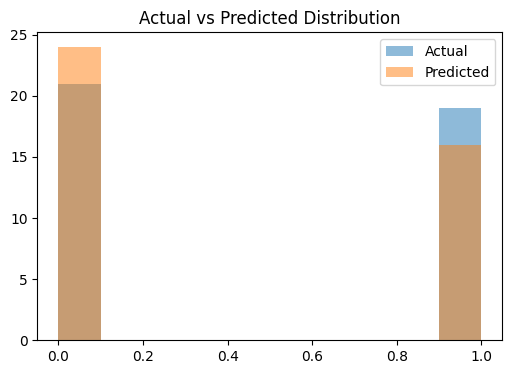

In [61]:
plt.figure(figsize=(6,4))
plt.hist(y_test, alpha=0.5, label='Actual')
plt.hist(y_pred, alpha=0.5, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Distribution")
plt.show()

In [62]:
import joblib

joblib.dump(svm_model, "cats_dogs_model.pkl")

['cats_dogs_model.pkl']

In [63]:
import cv2
import numpy as np
import joblib

model = joblib.load("cats_dogs_model.pkl")

def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (64, 64))
    img = img.flatten().reshape(1, -1)

    prediction = model.predict(img)

    if prediction[0] == 0:
        print("Prediction:Cat 🐱")
    else:
        print("Prediction:Dog 🐶")

In [64]:
predict_image("test_images/cat.jpg")
predict_image("test_images/dog.jpg")

Prediction:Cat 🐱
Prediction:Dog 🐶


## Conclusion

In this project, an SVM-based image classification model was developed to distinguish between cats and dogs. The images were preprocessed by resizing and converting into numerical feature vectors. The dataset was then split into training and testing sets.

A linear SVM classifier was trained on the extracted features and evaluated using accuracy score and classification report. The results demonstrate the model's ability to classify images with reasonable performance.

This project helped in understanding the complete pipeline of image classification, including preprocessing, feature extraction, model training, and evaluation using machine learning techniques.